# `detectorreco2d` — track and cluster reconstruction

`detectorreco2d` turns `detectorsim2d` truth into what a real reconstruction
would actually measure: every *charged* particle's `(d0, phi0, pt)` smeared
into a **track**, every *showering* particle's total calorimeter deposit
smeared into a **cluster** — both by an independent Gaussian whose width
shrinks with energy, `sigma = a + b / x` (`x` = that track's own `pt`, or
that cluster's own truth `energy`).

**Muons get no special treatment in track reconstruction** — charged like
anything else, they become a track exactly like a pion would. What *does*
treat them differently is cluster reconstruction, which excludes them
entirely: a muon's calorimeter footprint is a thin MIP trail, not a shower,
so its only reconstructed object is a track.

Both `tracks` and `clusters` carry `jet_id`/`is_b_jet`/`species` straight
through from the particles table as truth passthrough — not something a
real reconstruction would know for free, but useful for validating (or, in
the next notebook, training) a downstream flavor-tagging exercise.

In [6]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from detectorsim2d.config import load_config as load_sim_config
from detectorsim2d.simulate import simulate_events

from detectorreco2d.config import load_config as load_reco_config
from detectorreco2d.reconstruct import reconstruct, resolution
from detectorreco2d.io import write_run, read_run

from viz_style import palette

## Simulating truth to reconstruct

`configs/full_detector.yaml` (the same layout `03_detectorsim2d_event_simulation`
uses) ships a tracker, ECAL, HCAL, and muon system in one piecewise field —
enough for both tracks *and* clusters to actually be produced. Its own gun
draws only 8 particles per event; overriding `n_events` gives enough
statistics for the resolution plots below.

In [ ]:
sim_config = load_sim_config("../simulator/detectorsim2d/configs/full_detector.yaml")
sim_config.n_events = 300

rng = np.random.default_rng(42)
particles, hits, deposits = simulate_events(sim_config, rng=rng)
print(f"particles: {particles.shape}, hits: {hits.shape}, deposits: {deposits.shape}")
particles[["particle_id", "species", "charge", "energy"]].head()

FileNotFoundError: [Errno 2] No such file or directory: '../aihep/simulator/detectorsim2d/configs/full_detector.yaml'

## Reconstructing: tracks and clusters

`configs/default.yaml` sets a real (non-zero) resolution for every smeared
quantity -- unlike `RecoConfig()`'s all-zero default (exact passthrough,
the test suite's own baseline). `reconstruct` is the two-call convenience
wrapper around `reconstruct_tracks`/`reconstruct_clusters`.

In [ ]:
reco_config = load_reco_config("../reconstruction/detectorreco2d/configs/default.yaml")
print("track resolution:", reco_config.track)
print("cluster resolution:", reco_config.cluster)

tracks, clusters = reconstruct(particles, deposits, reco_config, rng=np.random.default_rng(reco_config.seed))
print(f"tracks: {tracks.shape}, clusters: {clusters.shape}")
tracks[["species", "charge", "d0_true", "d0", "phi0_true", "phi0", "pt_true", "pt"]].head()

track resolution: TrackResolution(d0=Resolution(a=0.05, b=2.0), phi0=Resolution(a=0.001, b=0.02), pt=Resolution(a=0.05, b=1.0))
cluster resolution: ClusterResolution(energy=Resolution(a=0.05, b=2.0))
tracks: (1600, 12), clusters: (1723, 7)


,species,charge,d0_true,d0,phi0_true,phi0,pt_true,pt
0,mu+,1.0,0.000000e+00,0.027823,1.240099,1.239706,46.369657,46.369745
1,mu+,1.0,2.842171e-14,-0.028957,-2.336629,-2.337756,146.108063,146.057438
2,mu+,1.0,0.000000e+00,0.076601,-0.811799,-0.812327,279.494197,279.497419
3,pi-,-1.0,-0.000000e+00,0.031288,2.027969,2.028376,144.155976,144.120648
4,mu+,1.0,0.000000e+00,-0.057140,-1.713808,-1.713841,175.283740,175.289612


Every *charged* particle became a track; every *showering* (EM/hadronic) particle became a cluster:

In [4]:
clusters[["species", "energy_true", "energy"]].head()

,species,energy_true,energy
0,pi0,141.979506,142.053446
1,neutron,221.671067,221.715113
2,pi-,149.346902,149.369051
3,electron,199.564394,199.576792
4,electron,121.710118,121.650087


## The resolution law

`sigma = a + b / x` — dominated by `b / x` at low `x`, asymptoting to the
floor `a` as `x` grows. Same shape for all four smeared quantities, just
different `(a, b)`:

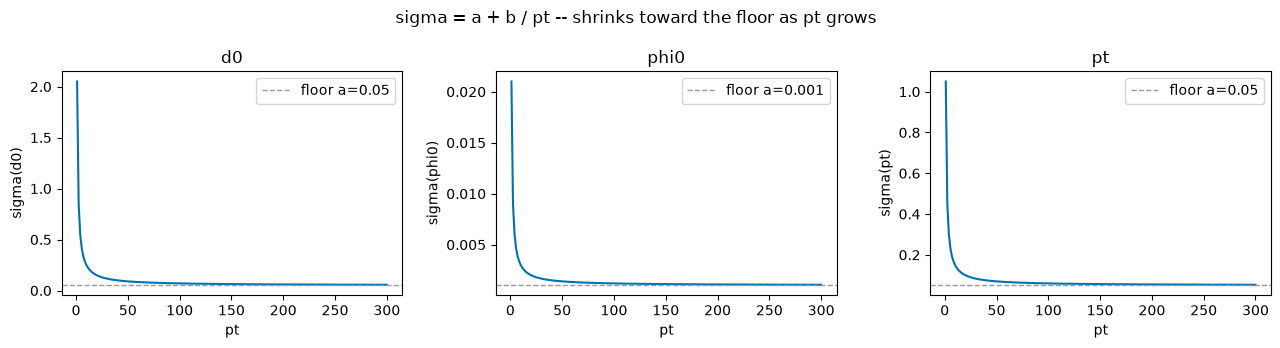

In [5]:
x = np.linspace(1.0, 300.0, 200)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, res) in zip(
    axes, [("d0", reco_config.track.d0), ("phi0", reco_config.track.phi0), ("pt", reco_config.track.pt)]
):
    ax.plot(x, [resolution(res.a, res.b, xi) for xi in x], color=palette.CATEGORICAL_OKABE_ITO[0])
    ax.axhline(res.a, color="0.6", linestyle="--", linewidth=1, label=f"floor a={res.a}")
    ax.set_xlabel("pt")
    ax.set_ylabel(f"sigma({name})")
    ax.set_title(name)
    ax.legend()
fig.suptitle("sigma = a + b / pt -- shrinks toward the floor as pt grows")
fig.tight_layout()

## Track residuals: does the smearing match the resolution law?

Binning tracks by their own truth `pt` and comparing the *observed*
residual std in each bin against `resolution()`'s *predicted* sigma at that
bin's mean `pt` directly checks that `reconstruct_tracks` actually draws
from the Gaussian it claims to -- not just for `pt` itself, but for `d0`/
`phi0` too, since all three use `pt` as the scale variable `x`.

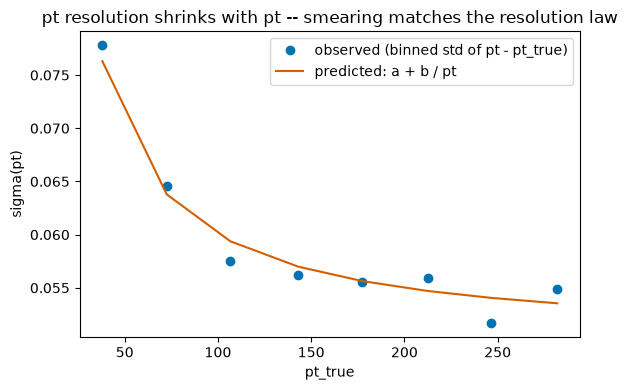

In [6]:
def binned_resolution(df, true_col, meas_col, a, b, n_bins=8):
    edges = np.linspace(df[true_col].min(), df[true_col].max(), n_bins + 1)
    df = df.copy()
    df["_bin"] = pd.cut(df[true_col], edges)
    g = df.groupby("_bin", observed=True).apply(
        lambda d: pd.Series({"x": d[true_col].mean(), "observed_sigma": (d[meas_col] - d[true_col]).std(), "n": len(d)})
    )
    g["predicted_sigma"] = [resolution(a, b, xi) for xi in g["x"]]
    return g.dropna()


pt_res = binned_resolution(tracks, "pt_true", "pt", reco_config.track.pt.a, reco_config.track.pt.b)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(pt_res["x"], pt_res["observed_sigma"], "o", color=palette.CATEGORICAL_OKABE_ITO[0],
        label="observed (binned std of pt - pt_true)")
ax.plot(pt_res["x"], pt_res["predicted_sigma"], "-", color=palette.CATEGORICAL_OKABE_ITO[1],
        label="predicted: a + b / pt")
ax.set_xlabel("pt_true")
ax.set_ylabel("sigma(pt)")
ax.set_title("pt resolution shrinks with pt -- smearing matches the resolution law")
ax.legend()
fig.tight_layout()

## d0 and phi0 pulls

A **pull** (`(measured - true) / predicted_sigma`) should look like a
standard normal if the smearing genuinely matches the resolution law used
to predict it -- unlike the raw residual above, a pull is comparable across
tracks with different `pt` (and therefore different `sigma`).

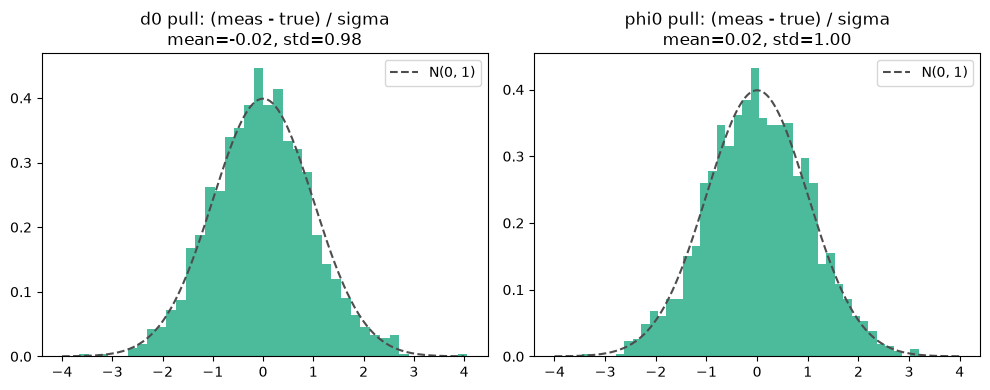

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, res) in zip(axes, [("d0", reco_config.track.d0), ("phi0", reco_config.track.phi0)]):
    true_col, meas_col = f"{name}_true", name
    sigma = tracks["pt_true"].apply(lambda xi: resolution(res.a, res.b, xi))
    pull = (tracks[meas_col] - tracks[true_col]) / sigma

    ax.hist(pull, bins=40, color=palette.CATEGORICAL_OKABE_ITO[2], alpha=0.7, density=True)
    xs = np.linspace(-4, 4, 200)
    ax.plot(xs, np.exp(-(xs**2) / 2) / np.sqrt(2 * np.pi), color="0.3", linestyle="--", label="N(0, 1)")
    ax.set_title(f"{name} pull: (meas - true) / sigma\nmean={pull.mean():.2f}, std={pull.std():.2f}")
    ax.legend()
fig.tight_layout()

## Cluster energy: truth vs. reconstructed

Same resolution law, applied to each showering particle's total truth
calorimeter deposit (summed across every cell/layer/system it hit).

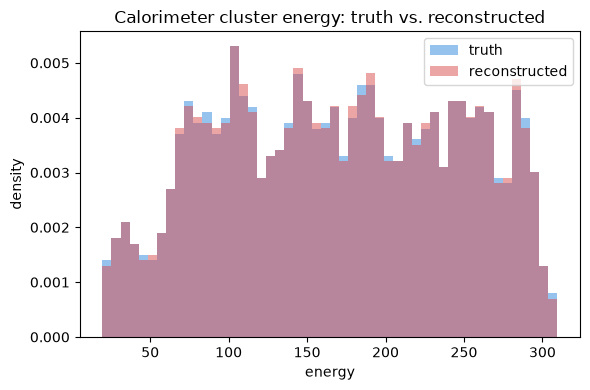

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
edges = np.histogram_bin_edges(clusters["energy_true"], bins=50)
ax.hist(clusters["energy_true"], bins=edges, color=palette.TRUTH, alpha=0.5, density=True, label="truth")
ax.hist(clusters["energy"], bins=edges, color=palette.CLUSTER, alpha=0.5, density=True, label="reconstructed")
ax.set_xlabel("energy")
ax.set_ylabel("density")
ax.set_title("Calorimeter cluster energy: truth vs. reconstructed")
ax.legend()
fig.tight_layout()

## Muons: a track, never a cluster

A muon's MIP trail through the calorimeters is excluded from
`reconstruct_clusters` -- its only reconstructed object is a track, exactly
like `species`-free charged particles or a charged pion, except a pion's
ECAL MIP + HCAL shower *does* sum into a cluster:

In [9]:
muon_tracks = tracks[tracks["species"].isin(["mu-", "mu+"])]
muon_clusters = clusters[clusters["species"].isin(["mu-", "mu+"])]
print(f"muon tracks:   {len(muon_tracks)}")
print(f"muon clusters: {len(muon_clusters)} (always zero -- a muon's MIP trail never forms a cluster)")

pi_tracks = tracks[tracks["species"].isin(["pi+", "pi-"])]
pi_clusters = clusters[clusters["species"].isin(["pi+", "pi-"])]
print(f"charged-pion tracks:   {len(pi_tracks)}")
print(f"charged-pion clusters: {len(pi_clusters)} (ECAL MIP + HCAL shower both count toward one cluster)")

muon tracks:   510
muon clusters: 0 (always zero -- a muon's MIP trail never forms a cluster)
charged-pion tracks:   564
charged-pion clusters: 481 (ECAL MIP + HCAL shower both count toward one cluster)


## IO round-trip

`write_run`/`read_run` store `tracks`/`clusters` as CSV or Apache Arrow,
mirroring `detectorsim2d.io`'s own convention -- `clusters` is optional
(a tracker-only run with no calorimeter has none).

In [10]:
import tempfile

with tempfile.TemporaryDirectory() as run_dir:
    write_run(run_dir, "arrow", tracks, clusters)
    tracks_back, clusters_back = read_run(run_dir, "arrow")

print(tracks_back.shape, clusters_back.shape)

(1600, 12) (1723, 7)


## Gotchas recap

- `RecoConfig()` (all `a=b=0`) is exact passthrough, not "very precise
  smearing" -- every reconstructed value equals its truth exactly, which is
  what the test suite's own baseline relies on.
- `pt` is floored at a tiny positive epsilon (`1e-6`); a Gaussian can wander
  through zero, which no real track (a curved-or-straight ray with a
  direction) can have. `d0`/`phi0` have no such floor -- they're smeared as
  plain unbounded Gaussians, so a wide-enough `phi0` resolution can in
  principle wander past `+-pi`.
- Cluster finding here is **truth-level**: `reconstruct_clusters` sums a
  particle's own deposits by `particle_id` rather than running a real
  cell-clustering algorithm -- see [`clustering/tracker`](../clustering/tracker)
  for that exercise on hits instead.
- `jet_id`/`is_b_jet`/`species` are truth passthrough columns a real
  reconstruction would not have for free -- the next notebook,
  `flavor_tagging`, is what they're actually for.